In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import normflows as nf
import random
from torch.utils.data import DataLoader
import pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# from GPDFlow import T_mGPD_NF
import Common_Functions as cf
import pickle
import scipy.stats as stats

/home/pgrad2/2448355h/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Using device: cuda


In [2]:
# Directory for saving plots and the model weights in all repeated experiments. Not uploaded to GitHub for file size considerations.
dir_out = "/home/pgrad2/2448355h/My_PhD_Project/01_Output/GPDFlow/"

#### Parameter settings for the T-representation mGPD with reverse exponential 

In [3]:
n_samples = 3000
n_experiments = 100    
d = 25
a = np.array([2, 0.5, 1, 1.7, 1.5,  2, 0.5, 1, 5,    1.5,2, 0.5, 1, 5, 1.5,  2, 0.5, 1, 5, 1.5,  2, 0.5, 1, 5, 1.5]) # alpha = 1/a, which is requred in computing the bivariate tail dependence coefficient
beta = np.array([1, 2, 3, 4, 5,  1, 2, 3, 4, 5,  1, 2, 3, 4, 5,   1, 2, 3, 4, 5,   1, 2, 3, 4, 5])
sig = np.array([0.5, 1.2, 1, 1.5, 0.8,  0.5, 1.2, 1, 1.5, 0.8,   0.5, 1.2, 1, 1.5, 0.8,   0.5, 1.2, 1, 1.5, 0.8,   0.5, 1.2, 1, 1.5, 0.8])
gamma = np.array([-0.1, 0.2, 0, 0.15, -0.05,  -0.1, 0.2, 0, 0.15, -0.05,  -0.1, 0.2, 0, 0.15, -0.05,  -0.1, 0.2, 0, 0.15, -0.05,   -0.1, 0.2, 0, 0.15, -0.05])

In [4]:
seed = 1234
random.seed(seed)
np.random.seed(seed)

samples = cf.sim_revexp_T_mgpd(n_samples, d, a[:d], beta[:d], sig[:d], gamma[:d])

# sns.pairplot(pd.DataFrame(samples), diag_kws={'bins': 10})

In [5]:
rng = np.random.default_rng(seed)  # set seed for reproducibility (change/remove if you want)
idx = rng.permutation(len(samples))

split = int(0.8 * len(samples))
train_idx, val_idx = idx[:split], idx[split:]

train_samples = samples[train_idx]
val_samples   = samples[val_idx]

## GPDFlow class with four different loss functions 

In [14]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class DataTransform(nn.Module):
    def __init__(self, dim, device, fix_margin):
        super().__init__()
        self.dim = dim
        if fix_margin:
            self.log_sigma = torch.zeros(dim, device=device)
            self.theta = torch.zeros(dim, device=device)
        else:
            self.log_sigma = nn.Parameter(torch.zeros(dim, device=device))
            self.theta = nn.Parameter(torch.zeros(dim, device=device))

    def get_sigma(self):
        sigma = torch.exp(self.log_sigma)
        sigma = torch.clamp(sigma, min=1e-6, max=1e6)
        return sigma

    def get_gamma(self):
        gamma = 0.5 * torch.tanh(self.theta)
        return gamma

    def forward_transform(self, y):
        sigma = self.get_sigma().unsqueeze(0)
        gamma = self.get_gamma().unsqueeze(0)

        sigma_b = sigma.expand_as(y)
        gamma_b = gamma.expand_as(y)

        # Reformulate sigma*expm1(gamma*y)/gamma as sigma*y*expm1(t)/t where t=gamma*y.
        # This avoids dividing by gamma, whose 1/gamma^2 backward gradient caused NaN
        # when |gamma| was near eps and quantile_lambda was large.
        t = gamma_b * y
        eps = 1e-3
        is_small = t.abs() < eps
        safe_t = torch.where(is_small, torch.ones_like(t), t)
        expm1_over_t = torch.where(
            is_small,
            1.0 + t / 2.0 + (t ** 2) / 6.0 + (t ** 3) / 24.0,
            torch.expm1(t) / safe_t,
        )
        return sigma_b * y * expm1_over_t

    def inverse_transform(self, x):
        sigma = self.get_sigma().unsqueeze(0)
        gamma = self.get_gamma().unsqueeze(0)

        sigma_b = sigma.expand_as(x)
        gamma_b = gamma.expand_as(x)

        # Reformulate log1p(gamma*x/sigma)/gamma as (x/sigma)*log1p(t)/t where t=gamma*x/sigma.
        # This avoids dividing by gamma, whose 1/gamma^2 backward gradient caused NaN
        # when |gamma| was near eps and quantile_lambda was large.
        w = x / sigma_b
        t = gamma_b * w
        t = torch.clamp(t, min=-1.0 + 1e-7)
        eps = 1e-3
        is_small = t.abs() < eps
        safe_t = torch.where(is_small, torch.ones_like(t), t)
        log1p_over_t = torch.where(
            is_small,
            1.0 - t / 2.0 + (t ** 2) / 3.0 - (t ** 3) / 4.0,
            torch.log1p(t) / safe_t,
        )
        return w * log1p_over_t

    def forward(self, z, reverse=False):
        return self.inverse_transform(z) if reverse else self.forward_transform(z)


class T_mGPD_NF(nn.Module):
    def __init__(
        self,
        dim,
        flow,
        device,
        s_min,
        s_max,
        num_integration_points,
        penalty_lambda,
        fix_margin,
        quantile_lambda=1.0,
        quantile_threshold=0.0,
        quantile_min_exceedances=5,
        mse_quantile_lambda=0.0,
        ad_lambda=0.0,
        moment_lambda=0.0,
        log_quantile_lambda=0.0,
    ):
        super().__init__()
        self.dim = dim
        self.device = device
        self.penalty_lambda = penalty_lambda
        self.quantile_lambda = quantile_lambda
        self.mse_quantile_lambda = mse_quantile_lambda
        self.ad_lambda = ad_lambda
        self.moment_lambda = moment_lambda
        self.log_quantile_lambda = log_quantile_lambda
        self.quantile_threshold = quantile_threshold
        self.quantile_min_exceedances = quantile_min_exceedances

        self.data_transform = DataTransform(dim, device, fix_margin)

        self.flow_model = flow
        self.s_values = torch.linspace(
            s_min, s_max, num_integration_points, device=device
        ).reshape(-1, 1, 1)
        self.s_min = s_min
        self.s_max = s_max
        self.num_integration_points = num_integration_points

    def get_sigma(self):
        return self.data_transform.get_sigma()

    def get_gamma(self):
        return self.data_transform.get_gamma()

    def log_integral_f_T(self, data):
        batch_size = data.shape[0]
        dim = data.shape[1]

        x_expanded = data.unsqueeze(0).expand(self.num_integration_points, -1, -1)
        s_expanded = self.s_values.expand(-1, batch_size, 1)
        x_plus_s = (x_expanded + s_expanded).reshape(-1, dim)

        log_f_T = self.flow_model.log_prob(x_plus_s)
        log_integrand = log_f_T.reshape(self.num_integration_points, batch_size)

        max_vals, _ = torch.max(log_integrand, dim=0, keepdim=True)
        stable_exp = torch.exp(log_integrand - max_vals)

        delta_s = (self.s_max - self.s_min) / (self.num_integration_points - 1)
        sum_exp = torch.trapz(stable_exp, dx=delta_s, dim=0)

        log_integral = max_vals.squeeze(0) + torch.log(sum_exp + 1e-20)
        return log_integral

    def log_prob_T_mGPD_std(self, data):
        log_integral = self.log_integral_f_T(data)
        max_T = torch.max(data, dim=1)[0]
        return log_integral - max_T

    def log_prob(self, x_data, very_negative=-1e30):
        sigma = self.get_sigma().unsqueeze(0)
        gamma = self.get_gamma().unsqueeze(0)
        inside_raw = sigma + gamma * x_data
        valid = (inside_raw > 0).all(dim=1)

        log_prob_x = torch.full(
            (x_data.size(0),),
            float(very_negative),
            device=x_data.device,
            dtype=x_data.dtype,
        )

        if valid.any():
            x_v = x_data[valid]
            inside_v = inside_raw[valid]
            y_v = self.data_transform.inverse_transform(x_v)
            log_prob_y_v = self.log_prob_T_mGPD_std(y_v)
            log_abs_detJ_v = -torch.sum(torch.log(inside_v), dim=1)
            log_prob_x[valid] = log_prob_y_v + log_abs_detJ_v

        return log_prob_x

    def _exceedance_mask(self, x_data, inside_raw):
        mask = (x_data > self.quantile_threshold) & (inside_raw > 0)
        active = mask.sum(dim=0) >= self.quantile_min_exceedances
        return mask, active

    def tail_quantile_loss(self, x_data, inside_raw):
        dtype = x_data.dtype
        device = x_data.device
        mask, active = self._exceedance_mask(x_data, inside_raw)

        if not active.any():
            return torch.tensor(0.0, device=device, dtype=dtype)

        y = self.data_transform.inverse_transform(x_data)

        loss_per_margin = torch.zeros(self.dim, device=device, dtype=dtype)
        for j in range(self.dim):
            if not active[j]:
                continue
            yj_sorted, _ = torch.sort(y[:, j][mask[:, j]])
            n_j = yj_sorted.shape[0]
            p = torch.arange(1, n_j + 1, device=device, dtype=dtype) / (n_j + 1)
            t = -torch.log(1.0 - p)
            pinball = p * torch.relu(t - yj_sorted) + (1.0 - p) * torch.relu(yj_sorted - t)
            loss_per_margin[j] = pinball.mean()

        return loss_per_margin[active].mean()

    def mse_quantile_loss(self, x_data, inside_raw):
        dtype = x_data.dtype
        device = x_data.device
        mask, active = self._exceedance_mask(x_data, inside_raw)

        if not active.any():
            return torch.tensor(0.0, device=device, dtype=dtype)

        y = self.data_transform.inverse_transform(x_data)

        loss_per_margin = torch.zeros(self.dim, device=device, dtype=dtype)
        for j in range(self.dim):
            if not active[j]:
                continue
            yj_sorted, _ = torch.sort(y[:, j][mask[:, j]])
            n_j = yj_sorted.shape[0]
            p = torch.arange(1, n_j + 1, device=device, dtype=dtype) / (n_j + 1)
            t = -torch.log(1.0 - p)
            loss_per_margin[j] = ((yj_sorted - t) ** 2).mean()

        return loss_per_margin[active].mean()

    def ad_quantile_loss(self, x_data, inside_raw):
        # Anderson-Darling-style: compare empirical vs theoretical Exp(1) CDF values
        # weighted by 1/(F*(1-F)) to emphasise tail deviations where gamma has most leverage.
        dtype = x_data.dtype
        device = x_data.device
        mask, active = self._exceedance_mask(x_data, inside_raw)

        if not active.any():
            return torch.tensor(0.0, device=device, dtype=dtype)

        y = self.data_transform.inverse_transform(x_data)

        loss_per_margin = torch.zeros(self.dim, device=device, dtype=dtype)
        for j in range(self.dim):
            if not active[j]:
                continue
            yj_sorted, _ = torch.sort(y[:, j][mask[:, j]])
            n_j = yj_sorted.shape[0]
            p = torch.arange(1, n_j + 1, device=device, dtype=dtype) / (n_j + 1)
            # Theoretical Exp(1) CDF at the sorted standardised values
            F_th = 1.0 - torch.exp(-yj_sorted.clamp(min=0.0))
            # Weight: large near 0 and 1 (tails), where GPD shape gamma matters most
            weights = 1.0 / (F_th * (1.0 - F_th)).clamp(min=1e-4)
            loss_per_margin[j] = (weights * (p - F_th) ** 2).mean()

        return loss_per_margin[active].mean()

    def moment_matching_loss(self, x_data, inside_raw):
        # Penalise deviation of mean and variance of standardised exceedances
        # from their Exp(1) values (mean=1, variance=1).
        dtype = x_data.dtype
        device = x_data.device
        mask, active = self._exceedance_mask(x_data, inside_raw)

        if not active.any():
            return torch.tensor(0.0, device=device, dtype=dtype)

        y = self.data_transform.inverse_transform(x_data)

        loss_per_margin = torch.zeros(self.dim, device=device, dtype=dtype)
        for j in range(self.dim):
            if not active[j]:
                continue
            yj = y[:, j][mask[:, j]]
            mean_loss = (yj.mean() - 1.0) ** 2
            var_loss  = (yj.var(correction=0)  - 1.0) ** 2
            loss_per_margin[j] = mean_loss + var_loss

        return loss_per_margin[active].mean()

    def log_quantile_loss(self, x_data, inside_raw):
        # MSE between log-transformed empirical and theoretical Exp(1) quantiles.
        # Log scale equalises contributions of small and large quantiles.
        dtype = x_data.dtype
        device = x_data.device
        mask, active = self._exceedance_mask(x_data, inside_raw)

        if not active.any():
            return torch.tensor(0.0, device=device, dtype=dtype)

        y = self.data_transform.inverse_transform(x_data)

        loss_per_margin = torch.zeros(self.dim, device=device, dtype=dtype)
        for j in range(self.dim):
            if not active[j]:
                continue
            yj_sorted, _ = torch.sort(y[:, j][mask[:, j]])
            n_j = yj_sorted.shape[0]
            p = torch.arange(1, n_j + 1, device=device, dtype=dtype) / (n_j + 1)
            t = -torch.log(1.0 - p)
            log_yj = torch.log(yj_sorted.clamp(min=1e-8))
            log_t  = torch.log(t)
            loss_per_margin[j] = ((log_yj - log_t) ** 2).mean()

        return loss_per_margin[active].mean()

    def loss_components(self, x_data, very_negative=-1e30, x_data_quantile=None):
        sigma = self.get_sigma().unsqueeze(0)
        gamma = self.get_gamma().unsqueeze(0)

        inside_raw = sigma + gamma * x_data
        valid = (inside_raw > 0).all(dim=1)

        log_prob_x = torch.full(
            (x_data.size(0),),
            float(very_negative),
            device=x_data.device,
            dtype=x_data.dtype,
        )

        if valid.any():
            x_v = x_data[valid]
            inside_v = inside_raw[valid]
            y_v = self.data_transform.inverse_transform(x_v)
            log_prob_y_v = self.log_prob_T_mGPD_std(y_v)
            log_abs_detJ_v = -torch.sum(torch.log(inside_v), dim=1)
            log_prob_x[valid] = log_prob_y_v + log_abs_detJ_v
            nll = -log_prob_x[valid].mean()
        else:
            nll = torch.tensor(0.0, device=x_data.device, dtype=x_data.dtype)

        negative_part = torch.relu(-inside_raw)
        support_loss = (negative_part ** 2).sum(dim=1).mean()

        if x_data_quantile is not None:
            x_q = x_data_quantile
            inside_raw_q = self.get_sigma().unsqueeze(0) + self.get_gamma().unsqueeze(0) * x_q
        else:
            x_q = x_data
            inside_raw_q = inside_raw

        quantile_loss = self.tail_quantile_loss(x_q, inside_raw_q)
        mse_q_loss    = self.mse_quantile_loss(x_q, inside_raw_q)
        ad_loss       = self.ad_quantile_loss(x_q, inside_raw_q)
        moment_loss   = self.moment_matching_loss(x_q, inside_raw_q)
        log_q_loss    = self.log_quantile_loss(x_q, inside_raw_q)

        support_loss_weighted  = self.penalty_lambda      * support_loss
        quantile_loss_weighted = self.quantile_lambda     * quantile_loss
        mse_q_loss_weighted    = self.mse_quantile_lambda * mse_q_loss
        ad_loss_weighted       = self.ad_lambda           * ad_loss
        moment_loss_weighted   = self.moment_lambda       * moment_loss
        log_q_loss_weighted    = self.log_quantile_lambda * log_q_loss

        total_loss = (
            nll
            + support_loss_weighted
            + quantile_loss_weighted
            + mse_q_loss_weighted
            + ad_loss_weighted
            + moment_loss_weighted
            + log_q_loss_weighted
        )

        return {
            "nll": nll,
            "support_loss": support_loss,
            "support_loss_weighted": support_loss_weighted,
            "quantile_loss": quantile_loss,
            "quantile_loss_weighted": quantile_loss_weighted,
            "mse_quantile_loss": mse_q_loss,
            "mse_quantile_loss_weighted": mse_q_loss_weighted,
            "ad_loss": ad_loss,
            "ad_loss_weighted": ad_loss_weighted,
            "moment_loss": moment_loss,
            "moment_loss_weighted": moment_loss_weighted,
            "log_quantile_loss": log_q_loss,
            "log_quantile_loss_weighted": log_q_loss_weighted,
            "total_loss": total_loss,
            "num_valid_rows": valid.sum(),
        }

    def forward(self, x_data, very_negative=-1e30, return_components=False, x_data_quantile=None):
        comps = self.loss_components(x_data, very_negative=very_negative, x_data_quantile=x_data_quantile)

        if return_components:
            return comps

        return comps["total_loss"]

    def sample(self, n_samples=1):
        self.flow_model.eval()
        samples_T, _ = self.flow_model.sample(n_samples)
        self.flow_model.train()

        samples_T_max = torch.max(samples_T, axis=1, keepdim=True)[0]
        samples_T_1 = samples_T - samples_T_max

        samples_E = torch.empty(n_samples, device=self.device).exponential_(1.0).unsqueeze(1)
        samples_y = samples_E + samples_T_1

        samples_x = self.data_transform.forward_transform(samples_y)
        return samples_x, samples_y, samples_T


In [7]:
def set_sigma_gamma_(model, true_sigma, true_gamma, eps=1e-12):
    """
    model: T_mGPD_NF
    true_sigma: tensor/array-like shape (dim,), positive
    true_gamma: tensor/array-like shape (dim,), must be in (-0.5, 0.5) because gamma = 0.5*tanh(theta)
    """
    dt = model.data_transform
    device = next(model.parameters()).device

    true_sigma = torch.as_tensor(true_sigma, dtype=torch.float32, device=device)
    true_gamma = torch.as_tensor(true_gamma, dtype=torch.float32, device=device)

    # --- sigma -> log_sigma
    true_sigma = torch.clamp(true_sigma, min=1e-6, max=1e6)
    new_log_sigma = torch.log(true_sigma)

    # --- gamma -> theta via inverse of gamma = 0.5 * tanh(theta)
    # theta = atanh(2*gamma)
    # clamp to avoid atanh(±1)
    z = torch.clamp(2.0 * true_gamma, -1.0 + eps, 1.0 - eps)
    new_theta = 0.5 * (torch.log1p(z) - torch.log1p(-z))  # atanh(z)

    with torch.no_grad():
        if isinstance(dt.log_sigma, torch.nn.Parameter):
            dt.log_sigma.copy_(new_log_sigma)
        else:
            dt.log_sigma = new_log_sigma  # if fix_margin=True in your class

        if isinstance(dt.theta, torch.nn.Parameter):
            dt.theta.copy_(new_theta)
        else:
            dt.theta = new_theta

    return model

In [ ]:
import torch
import numpy as np
import random
from torch.utils.data import DataLoader

# --- Your existing setup code ---
dim = d
base = nf.distributions.DiagGaussian(dim)

num_layers = 6
torch.manual_seed(0)

latent_size = dim
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []
# flows += [nf.flows.ActNorm(latent_size)]

for i in range(num_layers):
    s = nf.nets.MLP([latent_size, 4 * latent_size, latent_size], init_zeros=True, output_fn='tanh')
    t = nf.nets.MLP([latent_size, 4 * latent_size, latent_size], init_zeros=True, output_fn='tanh')
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    flows += [nf.flows.ActNorm(latent_size)]

f_T_model = nf.NormalizingFlow(base, flows)
f_T_model = f_T_model.to(device)

batch_size = 64
epochs = 50

x_min = samples.min(axis=0)
x_max = samples.max(axis=0)

model = T_mGPD_NF(
    dim=dim,
    flow=f_T_model,
    device=device,
    s_min=-10,
    s_max=10,
    num_integration_points=1000,
    penalty_lambda=1e8,
    fix_margin=False,
    quantile_lambda=0,
    quantile_threshold=0,
    quantile_min_exceedances=1,
    mse_quantile_lambda=0,
    ad_lambda=0,
    moment_lambda=25,
    log_quantile_lambda=0,
)

optimizer = torch.optim.Adam(
    [
        {'params': model.flow_model.parameters(), 'lr': 1e-3},
        {'params': model.data_transform.log_sigma, 'lr': 5e-3},
        {'params': model.data_transform.theta, 'lr': 5e-3},
    ],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

print("Initial Sigma:", model.get_sigma().detach().cpu().numpy())
print("Initial Gamma:", model.get_gamma().detach().cpu().numpy())

seed = 1234
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

# Make tensors
train_data = torch.tensor(np.asarray(train_samples), dtype=torch.float32, device=device)
val_data = torch.tensor(np.asarray(val_samples), dtype=torch.float32, device=device)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, drop_last=False)

# ---- Early stopping config ----
patience = 15
min_delta = 0.0
best_val = float("inf")
best_state = None
bad_epochs = 0

train_loss_history = []
val_loss_history = []
loss_history = []

torch.autograd.set_detect_anomaly(True)

init_sigmas = []
init_gammas = []

print("Fitting Univariate Margins via Scipy...")
for i in range(dim):
    data_i = train_samples[train_samples[:, i] > 0, i]
    c, loc, scale = stats.genpareto.fit(data_i, floc=0)
    init_gammas.append(c)
    init_sigmas.append(scale)

init_gammas = np.array(init_gammas)
init_sigmas = np.array(init_sigmas)

print(f"Scipy Estimated Gammas: {init_gammas.round(3)}")
print(f"Scipy Estimated Sigmas: {init_sigmas.round(3)}")

# set_sigma_gamma_(model, init_sigmas, init_gammas)

# --- STATS TRACKING ---
def init_epoch_stats():
    return {
        "nll": 0.0,
        "support_loss": 0.0,
        "support_loss_weighted": 0.0,
        "quantile_loss": 0.0,
        "quantile_loss_weighted": 0.0,
        "mse_quantile_loss": 0.0,
        "mse_quantile_loss_weighted": 0.0,
        "ad_loss": 0.0,
        "ad_loss_weighted": 0.0,
        "moment_loss": 0.0,
        "moment_loss_weighted": 0.0,
        "log_quantile_loss": 0.0,
        "log_quantile_loss_weighted": 0.0,
        "total_loss": 0.0,
        "count": 0,
    }

def update_epoch_stats(stats_dict, comps, batch_size):
    stats_dict["nll"] += comps["nll"].item() * batch_size
    stats_dict["support_loss"] += comps["support_loss"].item() * batch_size
    stats_dict["support_loss_weighted"] += comps["support_loss_weighted"].item() * batch_size
    stats_dict["quantile_loss"] += comps["quantile_loss"].item() * batch_size
    stats_dict["quantile_loss_weighted"] += comps["quantile_loss_weighted"].item() * batch_size
    stats_dict["mse_quantile_loss"] += comps["mse_quantile_loss"].item() * batch_size
    stats_dict["mse_quantile_loss_weighted"] += comps["mse_quantile_loss_weighted"].item() * batch_size
    stats_dict["ad_loss"] += comps["ad_loss"].item() * batch_size
    stats_dict["ad_loss_weighted"] += comps["ad_loss_weighted"].item() * batch_size
    stats_dict["moment_loss"] += comps["moment_loss"].item() * batch_size
    stats_dict["moment_loss_weighted"] += comps["moment_loss_weighted"].item() * batch_size
    stats_dict["log_quantile_loss"] += comps["log_quantile_loss"].item() * batch_size
    stats_dict["log_quantile_loss_weighted"] += comps["log_quantile_loss_weighted"].item() * batch_size
    stats_dict["total_loss"] += comps["total_loss"].item() * batch_size
    stats_dict["count"] += batch_size


def finalize_epoch_stats(stats_dict):
    if stats_dict["count"] == 0:
        return stats_dict
    out = {}
    for k, v in stats_dict.items():
        if k == "count":
            out[k] = v
        else:
            out[k] = v / stats_dict["count"]
    return out
# ----------------------


for epoch in range(epochs):

    prev_ls = model.data_transform.log_sigma.detach().clone()
    prev_th = model.data_transform.theta.detach().clone()

    # ---------------- TRAIN ----------------
    model.train()
    train_stats = init_epoch_stats()

    for x_data in train_loader:
        comps = model(x_data, return_components=True, x_data_quantile=train_data)
        batch_loss = comps["total_loss"]

        if torch.isnan(batch_loss) or torch.isinf(batch_loss):
            print(f"[Epoch {epoch}] NaN/Inf detected in TRAIN loss. Stopping.")
            bad_epochs = patience
            break

        optimizer.zero_grad(set_to_none=True)
        batch_loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        bsz = x_data.shape[0]
        update_epoch_stats(train_stats, comps, bsz)
        loss_history.append(batch_loss.item())

    train_stats = finalize_epoch_stats(train_stats)
    train_epoch_loss = train_stats["total_loss"] if train_stats["count"] > 0 else float("inf")
    train_loss_history.append(train_epoch_loss)

    with torch.no_grad():
        d_ls = (model.data_transform.log_sigma - prev_ls).abs().mean().item()
        d_th = (model.data_transform.theta - prev_th).abs().mean().item()

    # ---------------- VALIDATION ----------------
    model.eval()
    val_stats = init_epoch_stats()

    with torch.no_grad():
        for x_val in val_loader:
            comps = model(x_val, return_components=True)
            val_loss = comps["total_loss"]

            if torch.isnan(val_loss) or torch.isinf(val_loss):
                print(f"[Epoch {epoch}] NaN/Inf detected in VAL loss. Stopping.")
                bad_epochs = patience
                break

            bsz = x_val.shape[0]
            update_epoch_stats(val_stats, comps, bsz)

    val_stats = finalize_epoch_stats(val_stats)
    val_epoch_loss = val_stats["total_loss"] if val_stats["count"] > 0 else float("inf")
    val_loss_history.append(val_epoch_loss)

    scheduler.step()

   # ---------------- LOGGING ----------------
    lr_now = scheduler.get_last_lr()[0]

    print(
        f"Epoch {epoch+1:4d}/{epochs} | "
        f"train_total={train_stats['total_loss']:.4f} | "
        f"val_total={val_stats['total_loss']:.4f} | "
        f"lr={lr_now:.3e} | Δlog_sigma={d_ls:.4f} | Δtheta={d_th:.4f}"
    )

    print(
        f"  TRAIN | "
        f"nll={train_stats['nll']:.4f} | "
        f"supp_w={train_stats['support_loss_weighted']:.4f} | "
        f"pin_w={train_stats['quantile_loss_weighted']:.4f} | "
        f"mse_q_w={train_stats['mse_quantile_loss_weighted']:.4f} | "
        f"ad_w={train_stats['ad_loss_weighted']:.4f} | "
        f"moment_w={train_stats['moment_loss_weighted']:.4f} | "
        f"log_q_w={train_stats['log_quantile_loss_weighted']:.4f}"
    )

    print(
        f"  VALID | "
        f"nll={val_stats['nll']:.4f} | "
        f"supp_w={val_stats['support_loss_weighted']:.4f} | "
        f"pin_w={val_stats['quantile_loss_weighted']:.4f} | "
        f"mse_q_w={val_stats['mse_quantile_loss_weighted']:.4f} | "
        f"ad_w={val_stats['ad_loss_weighted']:.4f} | "
        f"moment_w={val_stats['moment_loss_weighted']:.4f} | "
        f"log_q_w={val_stats['log_quantile_loss_weighted']:.4f}"
    )
    # -----------------------------------------

    # ---------------- EARLY STOPPING ----------------
    improved = (best_val - val_epoch_loss) > min_delta

    if improved:
        best_val = val_epoch_loss
        bad_epochs = 0
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
    else:
        bad_epochs += 1

    if len(val_loss_history) > 5:
        if (
            val_loss_history[-1] > min(val_loss_history[:-1])
            and train_loss_history[-1] < min(train_loss_history[:-1])
        ):
            pass

    if bad_epochs >= patience:
        print(
            f"Early stopping at epoch {epoch + 1} "
            f"(no val improvement for {patience} epochs)."
        )
        break

if best_state is not None:
    model.load_state_dict(best_state)

print("Final Gamma:", model.data_transform.get_gamma())
print("Final Sigma:", model.data_transform.get_sigma())

Initial Sigma: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1.]
Initial Gamma: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]
Fitting Univariate Margins via Scipy...
Scipy Estimated Gammas: [-0.091  0.226 -0.019  0.097  0.159 -0.112  0.202  0.053 -0.019 -0.343
 -0.101  0.194 -0.022 -0.437  0.11  -0.1    0.216 -0.022  0.049 -0.002
 -0.095  0.244  0.075  0.312  0.21 ]
Scipy Estimated Sigmas: [0.492 1.18  0.982 1.895 0.564 0.51  1.209 0.978 1.965 1.065 0.505 1.241
 1.176 2.089 0.775 0.506 1.154 1.074 1.938 0.885 0.505 1.145 0.954 1.609
 0.501]
Epoch    1/50 | train_total=114.6734 | val_total=61.1402 | lr=9.990e-04 | Δlog_sigma=0.1595 | Δtheta=0.1275
  TRAIN | nll=51.3446 | supp_w=0.0000 | pin_w=0.0000 | mse_q_w=0.0000 | ad_w=0.0000 | moment_w=63.3288 | log_q_w=0.0000
  VALID | nll=41.3509 | supp_w=0.0000 | pin_w=0.0000 | mse_q_w=0.0000 | ad_w=0.0000 | moment_w=19.7893 | log_q_w=0.0000
Epoch    2/50 | train_total=45.3240 | val_tot

In [30]:
1

1

In [36]:
# ad_lambda = 25， batch size = 64, clip norm = 1， lr= 5e-3
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1890,  0.1300, -0.1070,  0.1140, -0.0870, -0.1650,  0.1370, -0.0600,
         0.1100, -0.0910, -0.1770,  0.1280, -0.0500,  0.0740, -0.0670, -0.1630,
         0.1340, -0.0760,  0.1100, -0.0620, -0.1720,  0.1320, -0.0500,  0.1530,
        -0.0620], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5976, 1.3082, 1.0078, 1.6211, 0.7562, 0.5868, 1.3133, 1.0352, 1.7272,
        0.8190, 0.5950, 1.3408, 1.0864, 1.4004, 0.8716, 0.5969, 1.2900, 1.0546,
        1.7304, 0.8794, 0.5929, 1.3023, 1.0162, 1.8988, 0.7603],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
# quantile_lambda=25, batch size = 64, clip norm = 1， lr= 5e-3
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1710,  0.1040, -0.1140,  0.1170, -0.1360, -0.1660,  0.1170, -0.0940,
         0.0820, -0.1040, -0.1720,  0.0940, -0.0640,  0.0480, -0.0920, -0.1590,
         0.1090, -0.0870,  0.1110, -0.0810, -0.1680,  0.1050, -0.0690,  0.0940,
        -0.1250], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5352, 1.2701, 1.0185, 1.7058, 0.6348, 0.5320, 1.2599, 1.0458, 1.5763,
        0.8298, 0.5323, 1.3039, 1.1360, 1.3238, 0.7907, 0.5308, 1.2471, 1.0911,
        1.8129, 0.8295, 0.5346, 1.2654, 0.9953, 1.6113, 0.6010],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
# no loss, batch size = 64, clip norm = 1， lr= 5e-3
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.2160,  0.0790, -0.1300, -0.0160, -0.1470, -0.1950,  0.0840, -0.0930,
         0.0050, -0.1410, -0.2050,  0.0670, -0.0870,  0.0080, -0.1390, -0.1950,
         0.0750, -0.1030,  0.0000, -0.1340, -0.1990,  0.0730, -0.0880,  0.0160,
        -0.1440], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6230, 1.1862, 0.8297, 0.9515, 0.5798, 0.6143, 1.1915, 0.8539, 0.8583,
        0.5883, 0.6148, 1.2112, 0.8782, 0.9151, 0.5972, 0.6221, 1.1681, 0.9009,
        0.8773, 0.6233, 0.6201, 1.1822, 0.8497, 0.9303, 0.6056],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [29]:
# mse_quantile_lambda=25, batch size = 64, clip norm = 1， lr= 1e-2
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1490,  0.1900, -0.0400,  0.1670, -0.0360, -0.1220,  0.1980,  0.0140,
         0.1260, -0.0820, -0.1250,  0.1920,  0.0180,  0.0630, -0.0200, -0.1120,
         0.1950, -0.0110,  0.1290, -0.0240, -0.1180,  0.1970,  0.0110,  0.2090,
        -0.0100], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5591, 1.2491, 1.0300, 1.7738, 0.8758, 0.5330, 1.2647, 1.0771, 1.7703,
        0.8765, 0.5357, 1.2760, 1.1159, 1.3523, 1.0162, 0.5312, 1.2415, 1.0706,
        1.9314, 1.0110, 0.5358, 1.2810, 1.0659, 2.3439, 0.8704],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [27]:
# mse_quantile_lambda=25, batch size = 64, clip norm = 1， lr= 5e-3
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1520,  0.1910, -0.0430,  0.1660, -0.0360, -0.1200,  0.1970,  0.0140,
         0.1250, -0.0840, -0.1260,  0.1890,  0.0160,  0.0640, -0.0240, -0.1150,
         0.1910, -0.0120,  0.1380, -0.0250, -0.1190,  0.1900,  0.0080,  0.2070,
        -0.0110], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5629, 1.2740, 1.0375, 1.7769, 0.8757, 0.5301, 1.2671, 1.0692, 1.7724,
        0.8777, 0.5402, 1.2930, 1.1173, 1.3527, 1.0175, 0.5353, 1.2482, 1.0724,
        1.9078, 1.0089, 0.5405, 1.2848, 1.0685, 2.3221, 0.8701],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
#log_quantile_lambda=25
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1920,  0.1080, -0.0940,  0.1020, -0.0880, -0.1700,  0.1080, -0.0490,
         0.0980, -0.0710, -0.1550,  0.0970, -0.0560,  0.0620, -0.0550, -0.1660,
         0.1080, -0.0690,  0.0900, -0.0460, -0.1720,  0.1050, -0.0440,  0.1120,
        -0.0880], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5884, 1.2619, 0.9635, 1.5877, 0.6991, 0.5782, 1.2942, 0.9504, 1.6851,
        0.7694, 0.5669, 1.3096, 1.0958, 1.4037, 0.7950, 0.5880, 1.2478, 1.0445,
        1.5286, 0.7951, 0.5870, 1.2592, 0.9684, 1.6569, 0.6519],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
#moment_matching_loss = 25
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.2080,  0.1370, -0.0700,  0.1550, -0.0720, -0.1880,  0.1380, -0.0150,
         0.1070, -0.1090, -0.1820,  0.1350, -0.0180,  0.0210, -0.0480, -0.1850,
         0.1330, -0.0470,  0.1370, -0.0580, -0.1850,  0.1380, -0.0150,  0.1650,
        -0.0520], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6214, 1.4040, 1.0707, 1.5926, 0.8507, 0.6210, 1.3931, 1.1087, 1.5327,
        0.8019, 0.6044, 1.4136, 1.1539, 1.1860, 0.9742, 0.6246, 1.3779, 1.1177,
        1.6037, 0.9550, 0.6177, 1.4079, 1.1097, 1.6706, 0.8608],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [21]:
# ad_lambda=25
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1960,  0.1040, -0.1040,  0.0960, -0.0810, -0.1730,  0.1100, -0.0610,
         0.0830, -0.0690, -0.1430,  0.1000, -0.0610,  0.0540, -0.0570, -0.1630,
         0.1030, -0.0720,  0.0880, -0.0510, -0.1710,  0.1010, -0.0510,  0.1310,
        -0.0660], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6082, 1.3074, 0.9858, 1.5038, 0.7602, 0.5979, 1.2996, 0.9966, 1.5083,
        0.8335, 0.5819, 1.3239, 1.0585, 1.3282, 0.8674, 0.6046, 1.2890, 1.0229,
        1.4889, 0.8751, 0.5994, 1.3024, 0.9991, 1.5952, 0.7651],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [18]:
# mse_quantile_lambda=25, batch size = 64, clip norm = 1
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1800,  0.1440, -0.0500,  0.1520, -0.0420, -0.1440,  0.1480,  0.0120,
         0.1240, -0.0750, -0.1460,  0.1440,  0.0090,  0.0630, -0.0230, -0.1430,
         0.1440, -0.0160,  0.1380, -0.0270, -0.1460,  0.1440,  0.0080,  0.1630,
        -0.0160], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5989, 1.3559, 1.0489, 1.6222, 0.8829, 0.5722, 1.3463, 1.0682, 1.6218,
        0.8704, 0.5721, 1.3645, 1.1277, 1.3531, 1.0184, 0.5796, 1.3313, 1.0812,
        1.6609, 1.0104, 0.5806, 1.3559, 1.0750, 1.7094, 0.8800],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
# pinball_loss=25, batch size = 64, clip norm = 1
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1850,  0.0890, -0.0990,  0.0700, -0.1110, -0.1700,  0.1000, -0.0770,
         0.0740, -0.0860, -0.1580,  0.0820, -0.0580,  0.0430, -0.0640, -0.1670,
         0.0930, -0.0640,  0.0760, -0.0530, -0.1730,  0.0900, -0.0610,  0.0860,
        -0.1160], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5474, 1.2859, 1.0046, 1.4611, 0.6731, 0.5399, 1.2764, 1.0275, 1.5092,
        0.8122, 0.5276, 1.3061, 1.1157, 1.3032, 0.8489, 0.5371, 1.2523, 1.0710,
        1.5385, 0.8615, 0.5393, 1.2766, 0.9885, 1.5396, 0.6521],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
# mse_quantile_lambda=25, batch size = 64, clip norm = 0.5
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1800,  0.1440, -0.0500,  0.1520, -0.0420, -0.1440,  0.1480,  0.0120,
         0.1240, -0.0750, -0.1460,  0.1440,  0.0090,  0.0630, -0.0230, -0.1430,
         0.1440, -0.0160,  0.1380, -0.0270, -0.1460,  0.1440,  0.0080,  0.1630,
        -0.0160], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5989, 1.3557, 1.0488, 1.6221, 0.8829, 0.5722, 1.3465, 1.0682, 1.6218,
        0.8705, 0.5721, 1.3644, 1.1277, 1.3531, 1.0183, 0.5796, 1.3313, 1.0811,
        1.6609, 1.0103, 0.5806, 1.3557, 1.0750, 1.7095, 0.8801],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
# mse_quantile_lambda=50, batch size = 64
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1600,  0.1580, -0.0360,  0.1700, -0.0180, -0.1240,  0.1610,  0.0330,
         0.1380, -0.0730, -0.1300,  0.1590,  0.0240,  0.0640, -0.0130, -0.1210,
         0.1590, -0.0000,  0.1530, -0.0150, -0.1240,  0.1580,  0.0240,  0.1790,
         0.0130], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5700, 1.3277, 1.0332, 1.6794, 0.8601, 0.5404, 1.3169, 1.0441, 1.6796,
        0.8762, 0.5495, 1.3355, 1.1180, 1.3602, 1.0213, 0.5465, 1.2972, 1.0632,
        1.7303, 1.0127, 0.5495, 1.3281, 1.0566, 1.8131, 0.8368],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
# mse_quantile_lambda=50, batch size = 128
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1840,  0.1390, -0.0380,  0.1570, -0.0190, -0.1510,  0.1400,  0.0340,
         0.1330, -0.0710, -0.1560,  0.1380,  0.0230,  0.0680, -0.0130, -0.1490,
         0.1380, -0.0020,  0.1450, -0.0120, -0.1540,  0.1380,  0.0200,  0.1580,
         0.0150], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6059, 1.3536, 1.0368, 1.5463, 0.8600, 0.5898, 1.3445, 1.0409, 1.5545,
        0.8755, 0.5921, 1.3639, 1.1181, 1.3491, 1.0225, 0.5941, 1.3326, 1.0656,
        1.5743, 1.0098, 0.5982, 1.3559, 1.0615, 1.5926, 0.8320],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
# quantile_lambda=50
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.2070,  0.0830, -0.0870,  0.0750, -0.0990, -0.1880,  0.0810, -0.0690,
         0.0720, -0.0810, -0.1390,  0.0700, -0.0730,  0.0330, -0.0570, -0.1850,
         0.0800, -0.0740,  0.0750, -0.0450, -0.1930,  0.0780, -0.0510,  0.0860,
        -0.0990], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5966, 1.2950, 1.0234, 1.5016, 0.7055, 0.5963, 1.2863, 1.0475, 1.4867,
        0.8303, 0.6010, 1.3181, 1.1645, 1.3251, 0.8712, 0.5994, 1.2637, 1.0930,
        1.5085, 0.8910, 0.6008, 1.2872, 0.9979, 1.5046, 0.6872],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [12]:
# quantile_lambda=30
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1950,  0.0810, -0.0890,  0.0500, -0.0930, -0.1750,  0.0770, -0.0670,
         0.0610, -0.0760, -0.1110,  0.0680, -0.0620,  0.0310, -0.0620, -0.1700,
         0.0760, -0.0700,  0.0560, -0.0510, -0.1820,  0.0740, -0.0600,  0.0700,
        -0.0930], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6114, 1.3007, 1.0179, 1.3840, 0.7341, 0.6132, 1.2934, 1.0407, 1.4046,
        0.8284, 0.6253, 1.3226, 1.1390, 1.2865, 0.8731, 0.6169, 1.2726, 1.0842,
        1.4024, 0.8779, 0.6167, 1.2936, 0.9934, 1.4165, 0.7187],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
# quantile_lambda=10
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1730,  0.0720, -0.0980,  0.0100, -0.0790, -0.1520,  0.0680, -0.0710,
         0.0310, -0.0680, -0.0880,  0.0610, -0.0700,  0.0200, -0.0640, -0.1470,
         0.0670, -0.0740,  0.0230, -0.0560, -0.1570,  0.0660, -0.0720,  0.0380,
        -0.0810], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6596, 1.2787, 0.9614, 1.1673, 0.8136, 0.6655, 1.2675, 0.9778, 1.1797,
        0.8377, 0.6857, 1.2942, 1.0230, 1.1455, 0.8841, 0.6687, 1.2659, 1.0029,
        1.1864, 0.8741, 0.6658, 1.2668, 0.9541, 1.2035, 0.7995],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
mse_quantile_lambda=30
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1960,  0.1260, -0.0470,  0.1400, -0.0350, -0.1650,  0.1270,  0.0220,
         0.1230, -0.0690, -0.1700,  0.1260,  0.0130,  0.0670, -0.0160, -0.1640,
         0.1240, -0.0100,  0.1350, -0.0200, -0.1700,  0.1260,  0.0130,  0.1450,
        -0.0060], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6258, 1.3537, 1.0460, 1.4813, 0.8760, 0.6202, 1.3462, 1.0491, 1.4887,
        0.8672, 0.6180, 1.3640, 1.1227, 1.3402, 1.0160, 0.6250, 1.3399, 1.0690,
        1.4997, 1.0091, 0.6284, 1.3550, 1.0682, 1.5028, 0.8650],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
# quantile_lambda=100.0, pitball loss
print(gamma[:d])
print(model.data_transform.get_gamma().round(decimals=3))

print(sig[:d])
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.2040,  0.0920, -0.0850,  0.1260, -0.1160, -0.2010,  0.0900, -0.0660,
         0.0890, -0.0940, -0.1950,  0.0780, -0.0910,  0.0210, -0.0400, -0.1970,
         0.0900, -0.0750,  0.1150, -0.0350, -0.1980,  0.0910, -0.0200,  0.1140,
        -0.1150], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5684, 1.2818, 1.0256, 1.6119, 0.6619, 0.5540, 1.2762, 1.0496, 1.5260,
        0.8306, 0.5500, 1.3092, 1.1961, 1.3477, 0.8688, 0.5560, 1.2500, 1.0989,
        1.6161, 0.8850, 0.5577, 1.2693, 0.9895, 1.5623, 0.6443],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [94]:

# ---------------- VALIDATION ----------------
para_dict = model.state_dict()
model.eval()
val_epoch_loss = 0.0
val_count = 0
with torch.no_grad():
    print(model.log_prob(torch.tensor(train_samples, dtype=torch.float32, device=device)).mean())




def set_sigma_gamma_(model, true_sigma, true_gamma, eps=1e-12):
    """
    model: T_mGPD_NF
    true_sigma: tensor/array-like shape (dim,), positive
    true_gamma: tensor/array-like shape (dim,), must be in (-0.5, 0.5) because gamma = 0.5*tanh(theta)
    """
    dt = model.data_transform
    device = next(model.parameters()).device

    true_sigma = torch.as_tensor(true_sigma, dtype=torch.float32, device=device)
    true_gamma = torch.as_tensor(true_gamma, dtype=torch.float32, device=device)

    # --- sigma -> log_sigma
    true_sigma = torch.clamp(true_sigma, min=1e-6, max=1e6)
    new_log_sigma = torch.log(true_sigma)

    # --- gamma -> theta via inverse of gamma = 0.5 * tanh(theta)
    # theta = atanh(2*gamma)
    # clamp to avoid atanh(±1)
    z = torch.clamp(2.0 * true_gamma, -1.0 + eps, 1.0 - eps)
    new_theta = 0.5 * (torch.log1p(z) - torch.log1p(-z))  # atanh(z)

    with torch.no_grad():
        if isinstance(dt.log_sigma, torch.nn.Parameter):
            dt.log_sigma.copy_(new_log_sigma)
        else:
            dt.log_sigma = new_log_sigma  # if fix_margin=True in your class

        if isinstance(dt.theta, torch.nn.Parameter):
            dt.theta.copy_(new_theta)
        else:
            dt.theta = new_theta

    return model

set_sigma_gamma_(model, sig, gamma)

with torch.no_grad():
    ll = model.log_prob(torch.tensor(train_samples, dtype=torch.float32, device=device))  # shape (batch,)
    mean_ll = ll.mean().item()
print("mean log-likelihood:", mean_ll)



tensor(-37.6175, device='cuda:0')
mean log-likelihood: -41.39990234375


In [ ]:
-model.data_transform.get_sigma()/model.data_transform.get_gamma()

tensor([ 4.0547, -3.9423,    -inf, -6.1086, 11.7557,  4.0547, -3.9423,    -inf,
        -6.1086, 11.7557,  4.0547, -3.9423,    -inf, -6.1086, 11.7557,  4.0547,
        -3.9423,    -inf, -6.1086, 11.7557,  4.0547, -3.9423,    -inf, -6.1086,
        11.7557], device='cuda:0', grad_fn=<DivBackward0>)

In [ ]:
train_samples[812,:]

array([ 0.38833883, -0.24393234, -0.68477038, -3.23170833, -2.42449575,
       -0.71203748,  0.26535432, -1.58613354, -8.97684823, -3.37160449,
       -0.18364804, -0.49847761, -6.03518523, -5.32618447, -9.0674058 ,
        0.64018657,  0.39563856, -0.89842771, -2.65299622, -2.73624275,
       -0.63559641,  0.60668126, -0.53414326, -7.07141497, -2.80366778])

In [ ]:
model.data_transform.log_sigma

Parameter containing:
tensor([1.0115, 0.9748], device='cuda:0', requires_grad=True)

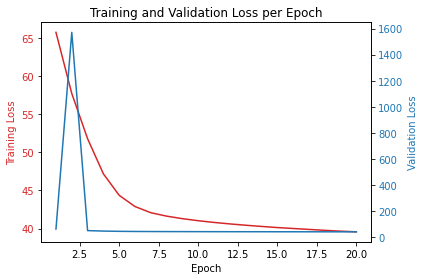

In [ ]:
fig, ax1 = plt.subplots()
epochs = range(1, len(train_loss_history) + 1)
color1 = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color=color1)
ax1.plot(epochs, train_loss_history, color=color1, label='Training Loss')
ax1.tick_params(axis='y', labelcolor=color1)

# Validation loss is calculated every 20 epochs.
# Create a list of epochs corresponding to validation measurements

# Create a second y-axis for validation loss
ax2 = ax1.twinx()
color2 = 'tab:blue'
ax2.set_ylabel('Validation Loss', color=color2)
ax2.plot(epochs, val_loss_history, color=color2, label='Validation Loss')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Training and Validation Loss per Epoch')
fig.tight_layout()
plt.show()

In [ ]:
print(gamma)
print(model.data_transform.get_gamma().round(decimals=3))

print(sig)
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.2160,  0.1010, -0.1110,  0.0060, -0.1000, -0.1970,  0.1050, -0.0700,
         0.0100, -0.1330, -0.1750,  0.0900, -0.0740,  0.0090, -0.1170, -0.1930,
         0.1020, -0.0870, -0.0000, -0.1060, -0.1880,  0.0950, -0.0710,  0.0080,
        -0.1140], device='cuda:0', grad_fn=<RoundBackward1>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6280, 1.1923, 0.8683, 0.8897, 0.7230, 0.6509, 1.1908, 0.8789, 0.8741,
        0.6442, 0.6026, 1.2177, 0.9185, 0.8989, 0.6673, 0.6418, 1.1962, 0.9122,
        0.8905, 0.7326, 0.6330, 1.1990, 0.8683, 0.9071, 0.6822],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
diff = gamma - model.data_transform.get_gamma().detach().cpu().numpy()
print(diff.round(3))

[0.399 0.697 0.497 0.165 0.425 0.398 0.698 0.497 0.176 0.423 0.397 0.697
 0.497 0.188 0.428 0.397 0.698 0.497 0.161 0.418 0.398 0.157 0.497 0.62
 0.431]


In [ ]:
diff = gamma - model.data_transform.get_gamma().detach().cpu().numpy()
print(diff.round(3))

[-0.09   0.181 -0.009  0.131 -0.058 -0.085  0.177 -0.011  0.129 -0.055
 -0.084  0.175 -0.012  0.133 -0.053 -0.089  0.176 -0.013  0.131 -0.052
 -0.081  0.179 -0.015  0.131 -0.057]


In [ ]:
diff = gamma - model.data_transform.get_gamma().detach().cpu().numpy()
print(diff.round(3))

[-0.071  0.187  0.006  0.147 -0.036 -0.082  0.187  0.024  0.145 -0.034
 -0.087  0.187  0.024  0.148 -0.031 -0.086  0.186  0.024  0.149 -0.042
 -0.079  0.186  0.023  0.146 -0.031]


In [ ]:
diff = gamma - model.data_transform.get_gamma().detach().cpu().numpy()
print(diff.round(3))

[0.043 0.069 0.053 0.1   0.03  0.048 0.073 0.051 0.11  0.042 0.049 0.074
 0.054 0.091 0.031 0.05  0.07  0.055 0.093 0.023 0.063 0.071 0.056 0.078
 0.029]


In [ ]:
diff = gamma - model.data_transform.get_gamma().detach().cpu().numpy()
print(diff.round(3))

[ 0.032  0.113  0.059  0.144  0.019  0.026  0.117  0.065  0.141 -0.
  0.079  0.112  0.075  0.144  0.021  0.021  0.121  0.063  0.141  0.
  0.069  0.111  0.075  0.142  0.013]


In [ ]:
print(gamma)
print(model.data_transform.get_gamma())

print(sig)
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.2090,  0.0772, -0.1261, -0.0010, -0.1453, -0.1916,  0.0765, -0.0839,
         0.0052, -0.1615, -0.1962,  0.0630, -0.0860, -0.0041, -0.1385, -0.1872,
         0.0712, -0.1013, -0.0057, -0.1429, -0.1913,  0.0631, -0.0834,  0.0069,
        -0.1289], device='cuda:0', grad_fn=<MulBackward0>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6047, 1.1421, 0.8126, 0.7657, 0.5492, 0.6197, 1.1451, 0.8408, 0.8112,
        0.5260, 0.6026, 1.1725, 0.8674, 0.8377, 0.5446, 0.6113, 1.1304, 0.8547,
        0.8153, 0.5871, 0.6034, 1.1617, 0.8149, 0.8458, 0.5714],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
print(gamma)
print(model.data_transform.get_gamma())

print(sig)
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.1331,  0.0670, -0.0588,  0.0118, -0.0267, -0.1318,  0.0607, -0.0742,
         0.0112, -0.0265, -0.1711,  0.0609, -0.0641,  0.0130, -0.0365, -0.0738,
         0.0532, -0.0503,  0.0120, -0.0476, -0.0595,  0.0725, -0.0532,  0.0098,
        -0.0424], device='cuda:0', grad_fn=<MulBackward0>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.5734, 1.0332, 0.7855, 0.8922, 0.8479, 0.5806, 1.0035, 0.7961, 0.9003,
        0.8631, 0.5653, 1.0302, 0.8005, 0.9065, 0.8194, 0.6476, 1.0556, 0.8109,
        0.8716, 0.8074, 0.6510, 1.0278, 0.7874, 0.9058, 0.7959],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
print(gamma)
print(model.data_transform.get_gamma())

print(sig)
print(model.data_transform.get_sigma())

[-0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2
  0.    0.15 -0.05 -0.1   0.2   0.    0.15 -0.05 -0.1   0.2   0.    0.15
 -0.05]
tensor([-0.2310,  0.0906, -0.0921, -0.0158, -0.1348, -0.2019,  0.0926, -0.1050,
        -0.0009, -0.1544, -0.1887,  0.1095, -0.0873,  0.0176, -0.1631, -0.1991,
         0.1040, -0.1139, -0.0134, -0.1445, -0.2142,  0.1058, -0.1149,  0.0075,
        -0.1582], device='cuda:0', grad_fn=<MulBackward0>)
[0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.  1.5 0.8 0.5 1.2 1.
 1.5 0.8 0.5 1.2 1.  1.5 0.8]
tensor([0.6700, 1.3832, 1.0146, 0.8555, 0.6551, 0.6169, 1.3036, 1.0025, 0.9098,
        0.6408, 0.6580, 1.3436, 1.0101, 0.9821, 0.6243, 0.5909, 1.3820, 0.9878,
        0.8278, 0.6287, 0.6487, 1.3474, 1.0374, 0.9298, 0.6215],
       device='cuda:0', grad_fn=<ClampBackward1>)


In [ ]:
print(gamma - model.data_transform.get_gamma().detach().cpu().numpy())



[0.13103647 0.10936436 0.09206404 0.16581298 0.08481365 0.10190813
 0.10735586 0.10496207 0.15092284 0.10441476 0.08874212 0.09051081
 0.08725818 0.1324198  0.1130965  0.09912039 0.0960432  0.11385597
 0.16344989 0.09446364 0.11421333 0.09424546 0.11486451 0.14254049
 0.10824895]


#### Fit a GPDFlow on the simulated data. Repeat for 100 times

In [ ]:
dim = 5
base = nf.distributions.DiagGaussian(dim)

with open(dir_out + f"/res_grid_search_simulation_1_dim_{dim}.pkl", "rb") as f:
    res_list = pickle.load(f)
best_overall = res_list[1]

hidden_mult = best_overall['hidden_mult']
num_layers = best_overall['num_layers']
epochs = best_overall['best_epoch']


torch.manual_seed(0)

latent_size = dim
b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
flows = []
for i in range(num_layers):
    s = nf.nets.MLP([latent_size, hidden_mult * latent_size, latent_size], init_zeros=True, output_fn='tanh')
    t = nf.nets.MLP([latent_size, hidden_mult * latent_size, latent_size], init_zeros=True, output_fn='tanh')
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    flows += [nf.flows.ActNorm(latent_size)]


f_T_model = nf.NormalizingFlow(base, flows)
f_T_model = f_T_model.to(device)

batch_size = 64
loss_history = []


model = T_mGPD_NF(dim=dim, flow =f_T_model, device=device, s_min=-10,
                  s_max = 10, num_integration_points=1000, penalty_lambda=10000, fix_margin=False)

optimizer = torch.optim.Adam([
    {'params': model.flow_model.parameters(), 'lr': 1e-2},  # Flow layers
    {'params': model.data_transform.log_sigma, 'lr': 1e-1},  # Faster for log_sigma
    {'params': model.data_transform.theta, 'lr': 1e-1}       # Faster for gamma
], weight_decay = 1e-5 )

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)

seed = 1234
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU setups

for i in range(n_experiments):
    

    samples = cf.sim_revexp_T_mgpd(n_samples, dim, a, beta, sig, gamma)

    data = torch.tensor(samples, dtype=torch.float, device = device)

    memory = torch.cuda.memory_allocated(device) /10**9

    Training_Data = DataLoader(data, batch_size=batch_size, shuffle=True)
    torch.autograd.set_detect_anomaly(True)

    for epoch in range(epochs):
        epoch_loss = 0.0
        
        for x_data in Training_Data:
            # Sample a batch of data from h_U

            batch_loss = model(x_data)

            # Backpropagation
            optimizer.zero_grad()
            batch_loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()

            # Record loss
            loss_history.append(batch_loss.item())
            epoch_loss += batch_loss.item()

            if torch.isnan(batch_loss) or torch.isinf(batch_loss):
                print("NaN or Inf detected!")
                break

        # Debugging: Print shapes
        scheduler.step()
    torch.save(model.state_dict(), dir_out + f'model_{dim}D_100_{i}.pt')
    print(f"Completed Experiment {i} \n")



Completed Experiment 0 

Completed Experiment 1 

Completed Experiment 2 

Completed Experiment 3 

Completed Experiment 4 

Completed Experiment 5 

Completed Experiment 6 

Completed Experiment 7 

Completed Experiment 8 

Completed Experiment 9 

Completed Experiment 10 

Completed Experiment 11 

Completed Experiment 12 

Completed Experiment 13 

Completed Experiment 14 

Completed Experiment 15 

Completed Experiment 16 

Completed Experiment 17 

Completed Experiment 18 

Completed Experiment 19 

Completed Experiment 20 

Completed Experiment 21 

Completed Experiment 22 

Completed Experiment 23 

Completed Experiment 24 

Completed Experiment 25 

Completed Experiment 26 

Completed Experiment 27 

Completed Experiment 28 

Completed Experiment 29 

Completed Experiment 30 

Completed Experiment 31 

Completed Experiment 32 

Completed Experiment 33 

Completed Experiment 34 

Completed Experiment 35 

Completed Experiment 36 

Completed Experiment 37 

Completed Experiment 3

#### Compare the true $f_{\boldsymbol{T}}$ and fitted $f_{\boldsymbol{T}}$ from the normalizing flow

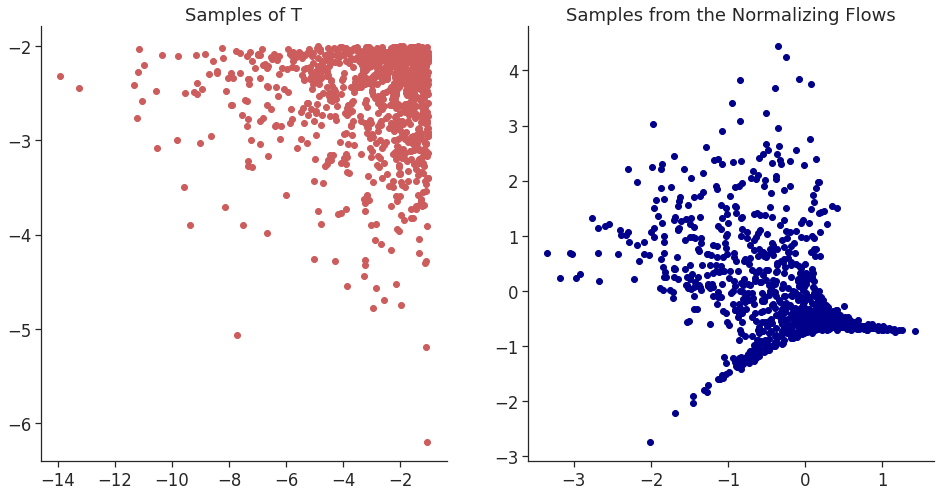

In [ ]:
seed = 1234
n = 1000
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU setups

T_total = []
for j in range(d):
    U = np.random.uniform(0, 1, n)
    T = a[j]*np.log(U) - beta[j]
    T_total.append(T)
T_total = np.column_stack(T_total)

model = cf.GPDFlow(2)

sns.set(style="ticks",font_scale=1.5)
plt.figure(figsize=(16,8))
plt.subplot(1, 2, 1)
plt.scatter(T_total[:,0], T_total[:,1], alpha=1, color='indianred')
model.load_state_dict(torch.load(dir_out + f'model_{2}D_100_{0}.pt', weights_only=True))
model.eval()
samples_obs, samples_std, samples_T= model.sample(n)
plt.title('Samples of T')

plt.subplot(1, 2, 2)
plt.scatter(samples_T[:,0].cpu().data.numpy(), samples_T[:,1].cpu().data.numpy(), alpha=1, color='darkblue')
plt.title('Samples from the Normalizing Flows')


sns.despine()
plt.savefig(dir_out + 'Plots/'+'f_T_sample.pdf',bbox_inches='tight')
plt.show()

#### Calculate the theorical pairwise $\chi$ based on formula in Kirkiriliouk's paper

In [ ]:
chi_values_theorical = cf.pairwise_chi_theorical(1/a)
chi_values_theorical

{'1-2': np.float64(0.5959389821791157),
 '1-3': np.float64(0.5645351568385462),
 '1-4': np.float64(0.3598892916940263),
 '1-5': np.float64(0.5318610619613964),
 '2-3': np.float64(0.71875),
 '2-4': np.float64(0.40792321620687566),
 '2-5': np.float64(0.6507777482864301),
 '3-4': np.float64(0.39186245321194657),
 '3-5': np.float64(0.612201755794261),
 '4-5': np.float64(0.3754625539543247)}

#### Calculate the empirical $\chi$ from the GPDFlow by 10000 Monte Carlo samples

In [ ]:
def GPDFlow(dim):
    """
    A quick set up of a GPDFlow with the architecture in the simulation section.

    Args: 
        dim (integer): dimension of the model
        model (NN.module): GPDFlow with initialization
        n_monte_carlo: number of samples from the model for monte carlo estimations
        n_experiments: number of repeat of the simulation scenario  
    
    Returns:
        model (NN.module): GPDFlow
    
    """
    base = nf.distributions.DiagGaussian(dim)

    with open(dir_out + f"/res_grid_search_simulation_1_dim_{dim}.pkl", "rb") as f:
        res_list = pickle.load(f)
    best_overall = res_list[1]

    hidden_mult = best_overall['hidden_mult']
    num_layers = best_overall['num_layers']

    torch.manual_seed(0)

    latent_size = dim
    b = torch.Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)])
    flows = []
    for i in range(num_layers):
        s = nf.nets.MLP([latent_size, hidden_mult * latent_size, latent_size], init_zeros=True, output_fn='tanh')
        t = nf.nets.MLP([latent_size, hidden_mult * latent_size, latent_size], init_zeros=True, output_fn='tanh')
        if i % 2 == 0:
            flows += [nf.flows.MaskedAffineFlow(b, t, s)]
        else:
            flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
        flows += [nf.flows.ActNorm(latent_size)]


    f_T_model = nf.NormalizingFlow(base, flows)
    f_T_model = f_T_model.to(device)



    model = T_mGPD_NF(dim=dim, flow =f_T_model, device=device, s_min=-10,
                    s_max = 10, num_integration_points=1000, penalty_lambda=10000, fix_margin=False)
    return model


def pairwise_chi_empirical(dim, n_monte_carlo, n_experiments=100):
    """
    Load the esimated Calculate the all empirical pairwise chi(p) of the data simulated by GPDFlow

    Args: 
        dim (integer): dimension of the model
        model (NN.module): GPDFlow with initialization
        n_monte_carlo: number of samples from the model for monte carlo estimations
        n_experiments: number of repeat of the simulation scenario  
    
    Returns:
        sample_chi (dict): dictionary with the name of dimension pairs as the key and a list of
        empirical chi in all experiments as the value
    """

    # Compute lambda_u for each quantile
    model = GPDFlow(dim)
    sample_chi = {}
    for i in range(dim-1):
        for j in range(i+1,dim):
            chi_values = []
            for _ in range(n_experiments):  # Step 3: Repeat 200 times
                # load the estimated weight
                model.load_state_dict(torch.load(dir_out + f'model_{dim}D_100_{_}.pt', weights_only=True))
                model.eval()
                samples_obs, samples_std, samples_T= model.sample(n_monte_carlo)
                sampled_data = samples_obs.cpu().data.numpy()
                chi_values.append(cf.empirical_upper_tail_dependence(sampled_data[:,[i,j]], 0.99))
            sample_chi[f"{i+1}-{j+1}"] =  chi_values
    
    return sample_chi


chi_values_empipical_2 = pairwise_chi_empirical(dim=2,  n_monte_carlo=10000)
chi_values_empipical_3 = pairwise_chi_empirical(dim=3,  n_monte_carlo=10000)
chi_values_empipical_5 = pairwise_chi_empirical(dim=5,  n_monte_carlo=10000)

#### Compare the fitted $\chi$ with the true value

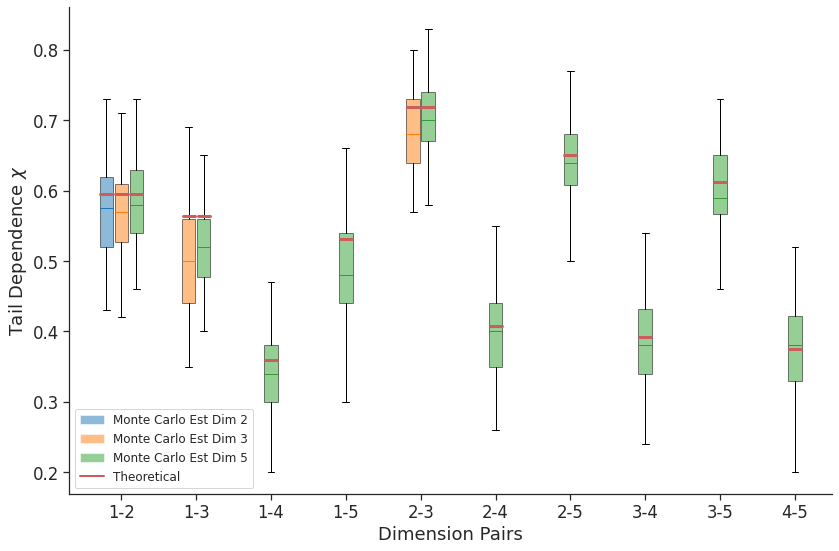

In [ ]:
pairs = ['1-2', '1-3', '1-4', '1-5', '2-3', '2-4', '2-5', '3-4', '3-5', '4-5']

# Use the keys from the 5-dimensional dictionary as the full set of pairs.
all_keys = sorted(chi_values_empipical_5.keys())  # sorted in lexicographical order; adjust as needed
x_positions = np.arange(len(all_keys))

delta = 0.2  # spacing factor for box positions

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare a mapping from each key to a list of tuples (dimension, data)
# We use all_keys as the base so that the x-axis remains consistent.
data_by_key = {key: [] for key in all_keys}
for dim, chi_dict in [(2, chi_values_empipical_2),
                      (3, chi_values_empipical_3),
                      (5, chi_values_empipical_5)]:
    for key, data in chi_dict.items():
        if key in data_by_key:
            data_by_key[key].append((dim, data))

colors = {2: '#1f77b4', 3: '#ff7f0e', 5: '#2ca02c'}
alpha_value = 0.5

# Loop over each key and plot the boxplots for the dimensions available.
for i, key in enumerate(all_keys):
    # Sort by dimension to maintain a consistent order (2, then 3, then 5)
    items = sorted(data_by_key[key], key=lambda x: x[0])
    n = len(items)
    if n == 0:
        continue  
    # Compute offsets so that the available boxplots are centered.
    offsets = [ (j - (n-1)/2) * delta for j in range(n) ]
    # Plot each available boxplot at the computed offset
    for offset, (dim, data) in zip(offsets, items):
        pos = x_positions[i] + offset
        bp = ax.boxplot(data, positions=[pos], widths=0.18,
                        patch_artist=True, showfliers=False)
        for patch in bp['boxes']:
            patch.set_facecolor(colors[dim])
            patch.set_alpha(alpha_value)
        for median in bp['medians']:
            median.set_color(colors[dim])
        # Plot the theoretical line if available.
        if key in chi_values_theorical:
            theory_val = chi_values_theorical[key]
            ax.plot([pos - 0.08, pos + 0.08],
                    [theory_val, theory_val],
                    color='indianred', lw=3)

# Set x-axis labels.
ax.set_xticks(x_positions)
ax.set_xticklabels(all_keys)
ax.set_xlabel("Dimension Pairs")
ax.set_ylabel(r"Tail Dependence $\chi$")

# Add legend.
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[dim], label=f'Monte Carlo Est Dim {dim}', alpha=alpha_value) for dim in [2, 3, 5]]
legend_elements.append(plt.Line2D([0], [0], color='indianred', lw=2, label='Theoretical'))
ax.legend(handles=legend_elements, loc='lower left',fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/'+f'Simulation_1_chi.pdf',bbox_inches='tight')
plt.show()

#### Get the estimated $\boldsymbol{\sigma}$ and $\boldsymbol{\gamma}$.

To get the estimated $\boldsymbol{\sigma}$ and $\boldsymbol{\gamma}$ from a single GPDFlow object called "model", one can use the following code:

model.data_transform.get_sigma()

model.data_transform.get_gamma()

In [ ]:
def marginal_parameter_monte_carlo(dim, n_experiments=100):
    """
    Load the estimated sigma and gamma of GPDFlow models in a simulation scenario, 
    and save them in two dictionaries.
    
    Args: 
        dim (integer): dimension of the model.
        n_experiments (integer): Number of repeat of the simulation
    
    Returns:
        sigma_dict(dict)， gamma_dict(dict): two dictionaries contains the estimated sigma and gamma of 
        GPDFlow models in a simulation scenario. 
    
    """
    sigma_dict = {f'{i+1}': [] for i in range(dim)}
    gamma_dict = {f'{i+1}': [] for i in range(dim)}
    model = GPDFlow(dim)
    for _ in range(n_experiments):  # Step 3: Repeat 200 times
        model.load_state_dict(torch.load(dir_out + f'model_{dim}D_100_{_}.pt', weights_only=True))
        model.eval()
        sigma_hat = model.data_transform.get_sigma().cpu().data.numpy()
        gamma_hat = model.data_transform.get_gamma().cpu().data.numpy()
        for i in range(dim):
            sigma_dict[f'{i+1}'].append(sigma_hat[i])
            gamma_dict[f'{i+1}'].append(gamma_hat[i])
    return sigma_dict, gamma_dict
sigma_dict_2, gamma_dict_2 = marginal_parameter_monte_carlo(2)
sigma_dict_3, gamma_dict_3 = marginal_parameter_monte_carlo(3)
sigma_dict_5, gamma_dict_5 = marginal_parameter_monte_carlo(5)

In [ ]:
sigma_true = dict(zip(['1', '2', '3', '4', '5'], sig))
gamma_true = dict(zip(['1', '2', '3', '4', '5'], gamma))

#### Compare the fitted $\boldsymbol{\sigma}$ with true values

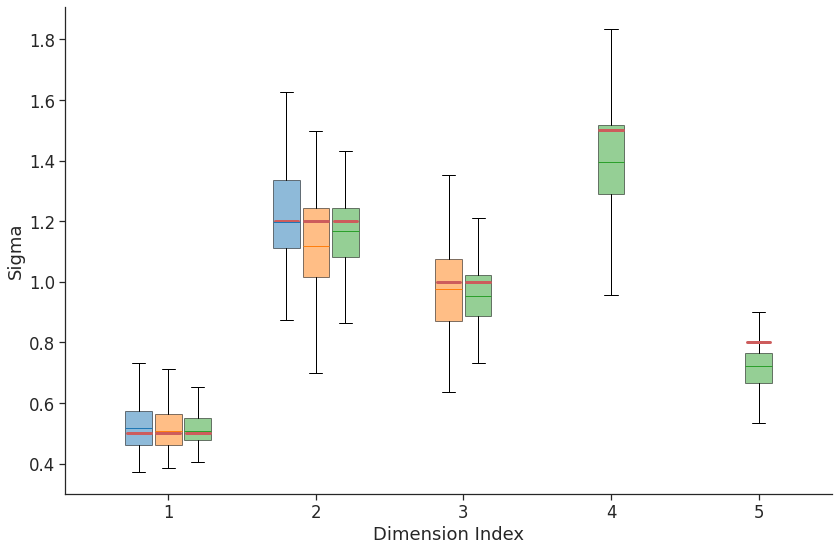

In [ ]:
pairs = ['1', '2', '3', '4', '5']

# Use the keys from the 5-dimensional dictionary as the full set of pairs.
all_keys = sorted(sigma_dict_5.keys())  
x_positions = np.arange(len(all_keys))

delta = 0.2  # spacing factor for box positions

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare a mapping from each key to a list of tuples (dimension, data)
# We use all_keys as the base so that the x-axis remains consistent.
data_by_key = {key: [] for key in all_keys}
for dim, chi_dict in [(2, sigma_dict_2),
                      (3, sigma_dict_3),
                      (5, sigma_dict_5)]:
    for key, data in chi_dict.items():
        if key in data_by_key:
            data_by_key[key].append((dim, data))

colors = {2: '#1f77b4', 3: '#ff7f0e', 5: '#2ca02c'}
alpha_value = 0.5

# Loop over each key and plot the boxplots for the dimensions available.
for i, key in enumerate(all_keys):
    # Sort by dimension to maintain a consistent order (2, then 3, then 5)
    items = sorted(data_by_key[key], key=lambda x: x[0])
    n = len(items)
    if n == 0:
        continue 
    # Compute offsets so that the available boxplots are centered.
    offsets = [ (j - (n-1)/2) * delta for j in range(n) ]
    # Plot each available boxplot at the computed offset
    for offset, (dim, data) in zip(offsets, items):
        pos = x_positions[i] + offset
        bp = ax.boxplot(data, positions=[pos], widths=0.18,
                        patch_artist=True, showfliers=False)
        for patch in bp['boxes']:
            patch.set_facecolor(colors[dim])
            patch.set_alpha(alpha_value)
        for median in bp['medians']:
            median.set_color(colors[dim])
        # Plot the theoretical line if available.
        if key in sigma_true:
            theory_val = sigma_true[key]
            ax.plot([pos - 0.08, pos + 0.08],
                    [theory_val, theory_val],
                    color='indianred', lw=3)

# Set x-axis labels.
ax.set_xticks(x_positions)
ax.set_xticklabels(all_keys)
ax.set_xlabel("Dimension Index")
ax.set_ylabel("Sigma")
# ax.set_title("Empirical Tail Dependence Boxplots with Theoretical Lines")

# Add legend.
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor=colors[dim], label=f'Monte Calro Results in Dim {dim}', alpha=alpha_value) for dim in [2, 3, 5]]
# legend_elements.append(plt.Line2D([0], [0], color='darkorange', lw=2, label='Theoretical'))
# ax.legend(handles=legend_elements, loc='best',fontsize=15)
sns.despine()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/'+f'Simulation_1_sigma.pdf',bbox_inches='tight')
plt.show()

#### Compare the fitted $\boldsymbol{\gamma}$ with true values

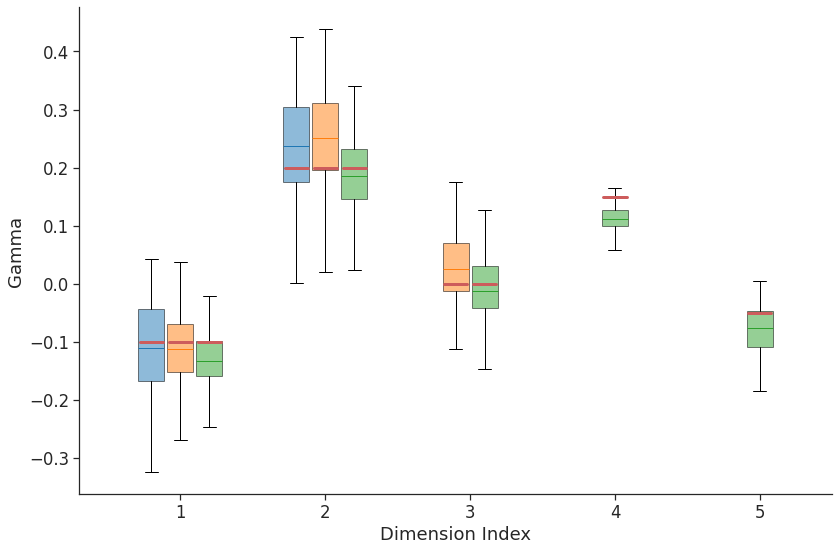

In [ ]:
pairs = ['1', '2', '3', '4', '5']

# Use the keys from the 5-dimensional dictionary as the full set of pairs.
all_keys = sorted(gamma_dict_5.keys())  
x_positions = np.arange(len(all_keys))

delta = 0.2  # spacing factor for box positions

sns.set(style="ticks", font_scale=1.5)
fig, ax = plt.subplots(figsize=(12, 8))

# Prepare a mapping from each key to a list of tuples (dimension, data)
# We use all_keys as the base so that the x-axis remains consistent.
data_by_key = {key: [] for key in all_keys}
for dim, chi_dict in [(2, gamma_dict_2),
                      (3, gamma_dict_3),
                      (5, gamma_dict_5)]:
    for key, data in chi_dict.items():
        if key in data_by_key:
            data_by_key[key].append((dim, data))

colors = {2: '#1f77b4', 3: '#ff7f0e', 5: '#2ca02c'}
alpha_value = 0.5

# Loop over each key and plot the boxplots for the dimensions available.
for i, key in enumerate(all_keys):
    # Sort by dimension to maintain a consistent order (2, then 3, then 5)
    items = sorted(data_by_key[key], key=lambda x: x[0])
    n = len(items)
    if n == 0:
        continue 
    # Compute offsets so that the available boxplots are centered.
    offsets = [ (j - (n-1)/2) * delta for j in range(n) ]
    # Plot each available boxplot at the computed offset
    for offset, (dim, data) in zip(offsets, items):
        pos = x_positions[i] + offset
        bp = ax.boxplot(data, positions=[pos], widths=0.18,
                        patch_artist=True, showfliers=False)
        for patch in bp['boxes']:
            patch.set_facecolor(colors[dim])
            patch.set_alpha(alpha_value)
        for median in bp['medians']:
            median.set_color(colors[dim])
        # Plot the theoretical line if available.
        if key in gamma_true:
            theory_val = gamma_true[key]
            ax.plot([pos - 0.08, pos + 0.08],
                    [theory_val, theory_val],
                    color='indianred', lw=3)
                
# Set x-axis labels.
ax.set_xticks(x_positions)
ax.set_xticklabels(all_keys)
ax.set_xlabel("Dimension Index")
ax.set_ylabel("Gamma")
# ax.set_title("Empirical Tail Dependence Boxplots with Theoretical Lines")

# Add legend.
# from matplotlib.patches import Patch
# legend_elements = [Patch(facecolor=colors[dim], label=f'Monte Calro Results in Dim {dim}', alpha=alpha_value) for dim in [2, 3, 5]]
# legend_elements.append(plt.Line2D([0], [0], color='darkorange', lw=2, label='Theoretical'))
# ax.legend(handles=legend_elements, loc='best',fontsize=15)
sns.despine()
plt.tight_layout()
plt.savefig(dir_out + 'Plots/'+f'Simulation_1_gamma.pdf',bbox_inches='tight')
plt.show()